# Лабораторна робота №3
## Візуалізація даних
**Виконав:** студент ФБ-44 Мажуга Ілля

**Мета роботи:**
1. Обрати унікальний датасет (Flight Delays).
2. Здійснити Data Cleaning.
3. Побудувати базові графіки (залежність атрибутів, гістограма на 5 діапазонів).
4. Побудувати багатовимірні графіки (за прикладами з Medium).

### 1. Завантаження та очищення даних (Data Cleaning)
Завантажуємо датасет про затримки авіарейсів. Видаляємо рядки з пропущеними значеннями (скасовані рейси), оскільки для побудови графіків нам потрібні повні числові дані.

In [1]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/PacktPublishing/Pandas-Cookbook/master/data/flights.csv"
df = pd.read_csv(url)

print("--- До очищення (Data Cleaning) ---")
print(f"Розмір датасету: {df.shape}")
print("\nКількість пропущених значень (Missing Values) у колонках:")
print(df[['AIRLINE', 'DEP_DELAY', 'ARR_DELAY', 'AIR_TIME']].isna().sum())

df.dropna(subset=['DEP_DELAY', 'ARR_DELAY', 'AIR_TIME'], inplace=True)

df.reset_index(drop=True, inplace=True)

print("\n--- Після очищення ---")
print(f"Розмір датасету: {df.shape}")
print("\nКількість пропусків тепер:")
print(df[['AIRLINE', 'DEP_DELAY', 'ARR_DELAY', 'AIR_TIME']].isna().sum())

df.head()

--- До очищення (Data Cleaning) ---
Розмір датасету: (58492, 14)

Кількість пропущених значень (Missing Values) у колонках:
AIRLINE         0
DEP_DELAY     833
ARR_DELAY    1018
AIR_TIME     1018
dtype: int64

--- Після очищення ---
Розмір датасету: (57474, 14)

Кількість пропусків тепер:
AIRLINE      0
DEP_DELAY    0
ARR_DELAY    0
AIR_TIME     0
dtype: int64


,MONTH,DAY,WEEKDAY,AIRLINE,ORG_AIR,DEST_AIR,SCHED_DEP,DEP_DELAY,AIR_TIME,DIST,SCHED_ARR,ARR_DELAY,DIVERTED,CANCELLED
0,1,1,4,WN,LAX,SLC,1625,58.0,94.0,590,1905,65.0,0,0
1,1,1,4,UA,DEN,IAD,823,7.0,154.0,1452,1333,-13.0,0,0
2,1,1,4,MQ,DFW,VPS,1305,36.0,85.0,641,1453,35.0,0,0
3,1,1,4,AA,DFW,DCA,1555,7.0,126.0,1192,1935,-7.0,0,0
4,1,1,4,WN,LAX,MCI,1720,48.0,166.0,1363,2225,39.0,0,0


### 2. Базові графіки (Scatter plot та Histogram)
Будуємо графік залежності часу польоту від дистанції, а також гістограму розподілу рейсів за 5 діапазонами дальності.

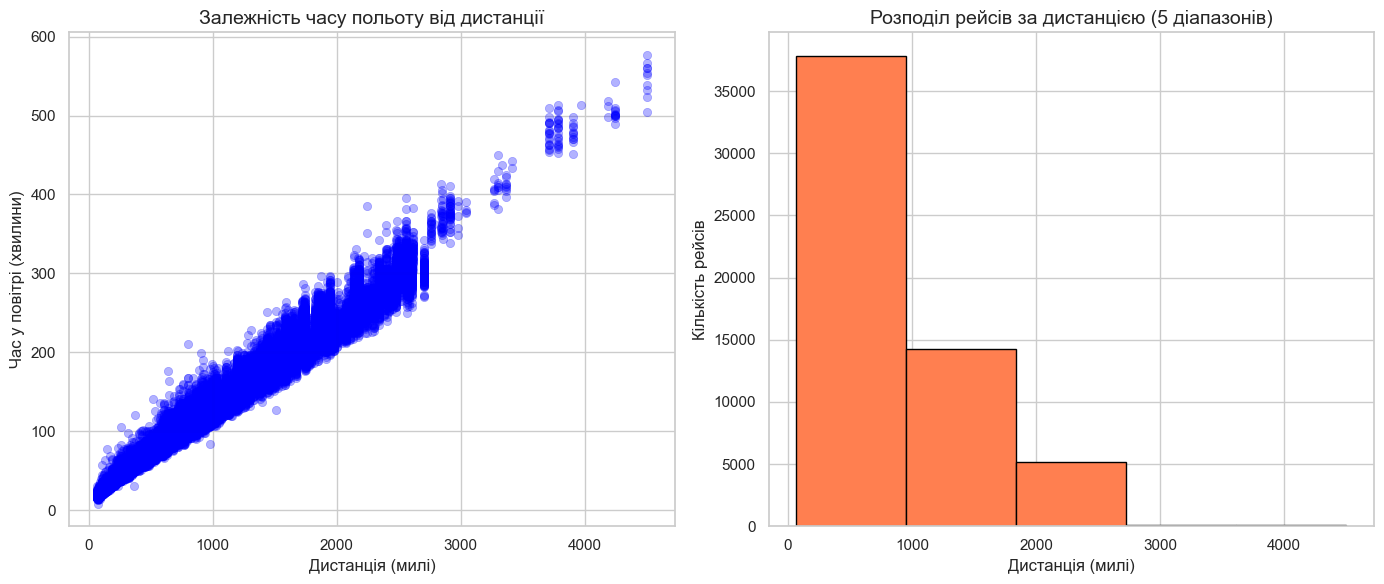

Межі 5 діапазонів гістограми (в милях): [  67.  954. 1841. 2728. 3615. 4502.]


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='DIST', y='AIR_TIME', alpha=0.3, color='blue', edgecolor=None)
plt.title('Залежність часу польоту від дистанції', fontsize=14)
plt.xlabel('Дистанція (милі)', fontsize=12)
plt.ylabel('Час у повітрі (хвилини)', fontsize=12)

plt.subplot(1, 2, 2)
counts, bins, patches = plt.hist(df['DIST'], bins=5, color='coral', edgecolor='black')
plt.title('Розподіл рейсів за дистанцією (5 діапазонів)', fontsize=14)
plt.xlabel('Дистанція (милі)', fontsize=12)
plt.ylabel('Кількість рейсів', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Межі 5 діапазонів гістограми (в милях): {bins}")

### 3. Багатовимірна візуалізація та додаткові графіки
За прикладами зі статті про ефективну візуалізацію багатовимірних даних, будуємо наступні графіки:
1. **Boxplot:** Розподіл затримок прибуття за авіакомпаніями.
2. **Heatmap:** Матриця кореляції для пошуку прихованих залежностей між числовими атрибутами.
3. **Multivariate Barplot:** Динаміка середніх затримок по днях тижня для топ-4 авіакомпаній.

C:\Users\Ілля\AppData\Local\Temp\ipykernel_27416\3323852490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AIRLINE', y='ARR_DELAY', palette='Set2')


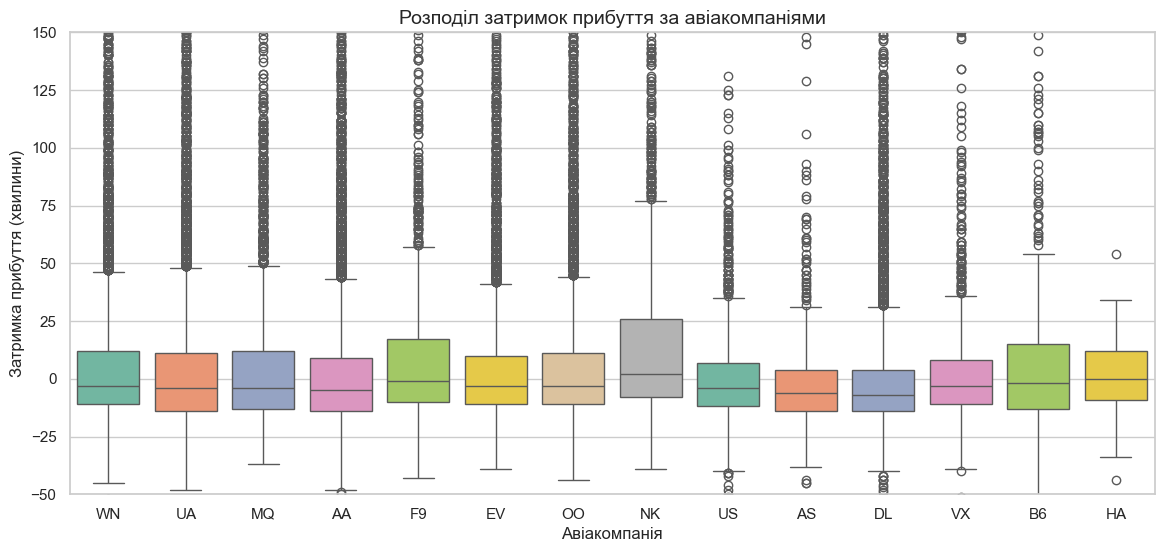

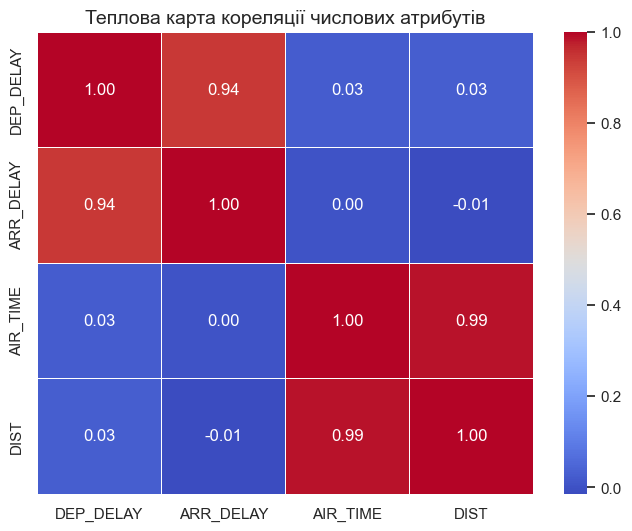

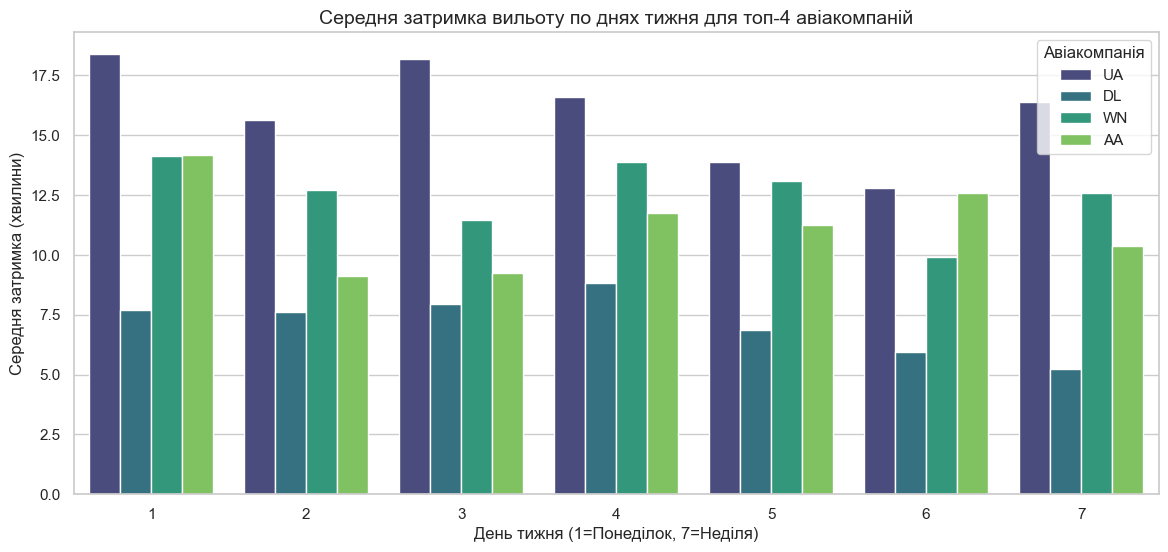

In [3]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='AIRLINE', y='ARR_DELAY', palette='Set2')
plt.ylim(-50, 150)
plt.title('Розподіл затримок прибуття за авіакомпаніями', fontsize=14)
plt.xlabel('Авіакомпанія', fontsize=12)
plt.ylabel('Затримка прибуття (хвилини)', fontsize=12)
plt.show()

plt.figure(figsize=(8, 6))
numeric_cols = df[['DEP_DELAY', 'ARR_DELAY', 'AIR_TIME', 'DIST']]
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Теплова карта кореляції числових атрибутів', fontsize=14)
plt.show()

plt.figure(figsize=(14, 6))
top_airlines = df['AIRLINE'].value_counts().index[:4]
df_top = df[df['AIRLINE'].isin(top_airlines)]

sns.barplot(data=df_top, x='WEEKDAY', y='DEP_DELAY', hue='AIRLINE', palette='viridis', errorbar=None)
plt.title('Середня затримка вильоту по днях тижня для топ-4 авіакомпаній', fontsize=14)
plt.xlabel('День тижня (1=Понеділок, 7=Неділя)', fontsize=12)
plt.ylabel('Середня затримка (хвилини)', fontsize=12)
plt.legend(title='Авіакомпанія')
plt.show()

### 4. Додаткові графіки (Тренди та Розподіл)
Покажемо ще корисну інформацію з датасету:
1. **Lineplot:** Динаміка середньої затримки вильоту по днях місяця.
2. **Countplot:** Загальна кількість рейсів для кожної авіакомпанії.

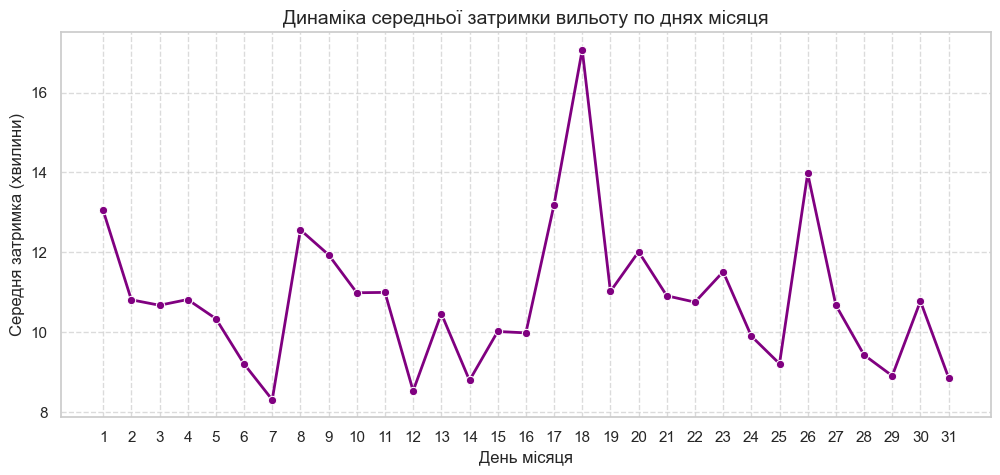

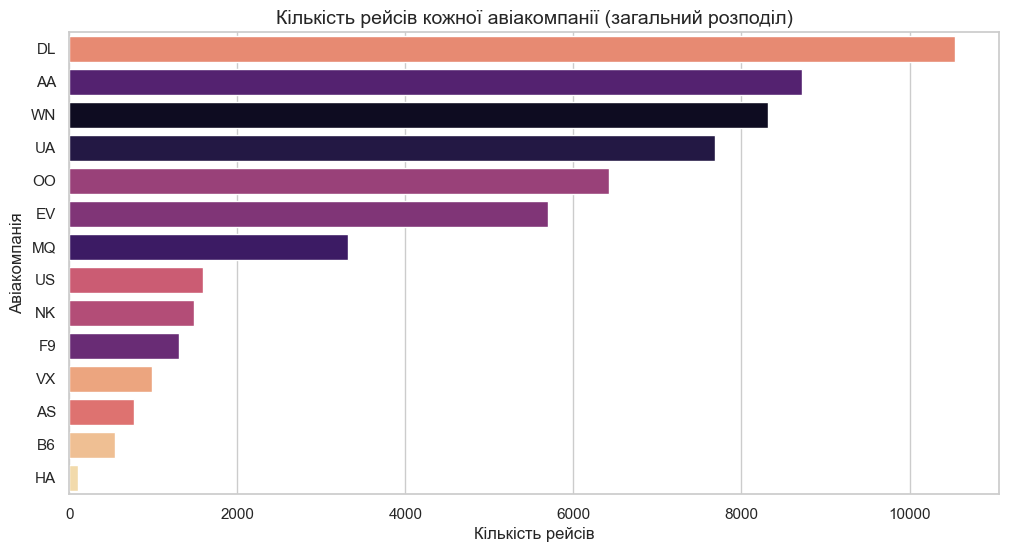

In [4]:
plt.figure(figsize=(12, 5))
daily_delay = df.groupby('DAY')['DEP_DELAY'].mean()

sns.lineplot(x=daily_delay.index, y=daily_delay.values, marker='o', color='purple', linewidth=2)
plt.title('Динаміка середньої затримки вильоту по днях місяця', fontsize=14)
plt.xlabel('День місяця', fontsize=12)
plt.ylabel('Середня затримка (хвилини)', fontsize=12)
plt.xticks(range(1, 32))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='AIRLINE', order=df['AIRLINE'].value_counts().index, hue='AIRLINE', palette='magma', legend=False)
plt.title('Кількість рейсів кожної авіакомпанії (загальний розподіл)', fontsize=14)
plt.xlabel('Кількість рейсів', fontsize=12)
plt.ylabel('Авіакомпанія', fontsize=12)
plt.show()